# Midterm

## importing the data

In [2]:
!pip install ucimlrepo

In [3]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# fetch dataset
air_quality = fetch_ucirepo(id=360)

# data (as pandas dataframes)
data = air_quality.data.features

# metadata
print(air_quality.metadata)

# variable information
print(air_quality.variables)

{'uci_id': 360, 'name': 'Air Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/360/air+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/360/data.csv', 'abstract': 'Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer. ', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 9358, 'num_features': 15, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C59K5F', 'creators': ['Saverio Vito'], 'intro_paper': {'ID': 420, 'type': 'NATIVE', 'title': 'On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario', 'authors': 

## Scanning for Null values

In [4]:
import numpy as np

df = data.replace(-200, np.nan)      # swap them all for NaN
print(df.isna().sum())

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


Here, I'm going through all the data and changing the -200 values to null because, as the websitestates, values = -200 in the data are null
There is quite a lot of them too
I also drop all nan columns because

## Info digestion

In [5]:
df = df.drop('NMHC(GT)', axis=1)

I dropped this column because more than 75% of the data inside of it was null
This would make imputation unreliable becuase I would have to deal with that large sum of null values, possibly skewing the results

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         7674 non-null   float64
 3   PT08.S1(CO)    8991 non-null   float64
 4   C6H6(GT)       8991 non-null   float64
 5   PT08.S2(NMHC)  8991 non-null   float64
 6   NOx(GT)        7718 non-null   float64
 7   PT08.S3(NOx)   8991 non-null   float64
 8   NO2(GT)        7715 non-null   float64
 9   PT08.S4(NO2)   8991 non-null   float64
 10  PT08.S5(O3)    8991 non-null   float64
 11  T              8991 non-null   float64
 12  RH             8991 non-null   float64
 13  AH             8991 non-null   float64
dtypes: float64(12), object(2)
memory usage: 1023.6+ KB


In [7]:
df.describe()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,7674.000000,8991.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,2.152750,1099.833166,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530
std,1.453252,217.080037,7.449820,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813
min,0.100000,647.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700
25%,1.100000,937.000000,4.400000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,11.800000,35.800000,0.736800
50%,1.800000,1063.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400
75%,2.900000,1231.000000,14.000000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700
max,11.900000,2040.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


In [8]:
print(df.select_dtypes(include="object").columns.tolist())

['Date', 'Time']


I just want to make sure the only columns containing strings are Data and Time

In [9]:
dt = pd.to_datetime(df["Date"])
df["weekday"] = dt.dt.dayofweek
df["month"] = dt.dt.month
df = df.drop(columns=["Date"])

Above, I realized, the entirety of date may cause memorization issues in the model
I didn't want it to start memorizing certain dates of the year so I extracted the weekdays and months.
This way, it may find patterns in the time of year but not exact dates

In [10]:
# Looking at the target value and it's data
df['CO(GT)'].describe()

,CO(GT)
count,7674.000000
mean,2.152750
std,1.453252
min,0.100000
25%,1.100000
50%,1.800000
75%,2.900000
max,11.900000


## Binning

In [11]:
df = df.dropna(subset=["CO(GT)"])
df["CO_class"], edges = pd.qcut(df["CO(GT)"], q=3, labels=[0, 1, 2], retbins=True)
df["CO_class"] = df["CO_class"].astype(int)

df['CO_class'].head()

,CO_class
0,2
1,1
2,1
3,1
4,1


I'm using CO(GT) as the target gas because carbon monoxide the most common pollutant from cars
It's also being binned for trainging purposes. If I left the info raw, it would try to guess the pure carbon monoxide numbers.
But with the binning, it is just guessing the level (low, moderate and high)
I had to drop the null values in the column as well

## Data Seperation

In [12]:
gt_cols = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]

X = df.drop(columns = gt_cols + ['CO_class'])
y_class = df['CO_class']
y_reg = df['CO(GT)']


I don't need the other gasses. They would just act as noise. But the sensors for them can provide valuable information
and not to mention, they also may pickup traces of the carbon monoxide.

## Checking skewedness

In [13]:
X.drop('Time', axis=1).skew()

,0
PT08.S1(CO),0.727450
PT08.S2(NMHC),0.531941
PT08.S3(NOx),1.151582
PT08.S4(NO2),0.219127
PT08.S5(O3),0.576986
T,0.377434
RH,-0.014976
AH,0.340406
weekday,-0.053761
month,0.245060


Because certain columns are heavily skewed, I am going to use median imputation on the numerical columns

## Create the Pipeline

In [14]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

num_cols = ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)", "PT08.S4(NO2)", "PT08.S5(O3)", "T", "RH" ,"AH"]
cat_cols = ['Time', 'weekday', 'month']

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("cat_encoder", OneHotEncoder()),
])

preprocess_pipe = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

Above, i deciced to use median because certain num columns are skewed heavily.
I also chose to use most_frequent imputation because I'm just used to it and I've see consistent results so far




In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, yc_train, yc_test, yr_train, yr_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class)

## Define the sgd model

In [16]:
from sklearn.base import clone
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, f1_score

def run_sgd(**param):
    pipe = Pipeline([
        ('preprocess', clone(preprocess_pipe)),
        ("sgd_clf", SGDClassifier(max_iter=1000, tol=1e-3, random_state=42, **param))
        ])
    pipe.fit(X_train, yc_train)
    pred = pipe.predict(X_test)
    return {**param, "accuracy": accuracy_score(yc_test, pred), "f1": f1_score(yc_test, pred, average="macro")}

This just allows me to import any number of parameters all at once
We are also using 1000 max iteration, but we will most likely not use them all
We also have a hard encoded stoppage. But I will probably change this for regularization later

## Loss function comparison

In [17]:
loss_df = pd.DataFrame([run_sgd(loss=l) for l in ["log_loss", "hinge", "modified_huber", "perceptron"]])
loss_df

,loss,accuracy,f1
0,log_loss,0.834528,0.831653
1,hinge,0.837134,0.833337
2,modified_huber,0.820195,0.813166
3,perceptron,0.805863,0.796265


After inputing all my known loss', we see that log_loss and hinge are the best. They have the highest F1 and accuracy
I am using log loss because it is a softmax family loss

## Alpha test

In [18]:
best_loss = "log_loss"
alpha_df = pd.DataFrame([run_sgd(loss=best_loss, alpha=a) for a in [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]])
alpha_df

,loss,alpha,accuracy,f1
0,log_loss,0.00001,0.835179,0.830874
1,log_loss,0.00010,0.834528,0.831653
2,log_loss,0.00100,0.838436,0.833706
3,log_loss,0.01000,0.813029,0.804012
4,log_loss,0.10000,0.739414,0.701808


After doing the above test for alpha variables, .001 is the best. It has the highest values for accuracy and f1

## Learning rate testing

In [19]:
best_alpha = 1e-3
lr_df = pd.DataFrame([run_sgd(loss=best_loss, alpha=best_alpha, learning_rate=lr, eta0=e)
                      for lr in ["invscaling", "optimal"] for e in [0.001, 0.01, 0.1]])
lr_df

,loss,alpha,learning_rate,eta0,accuracy,f1
0,log_loss,0.001,invscaling,0.001,0.676221,0.595894
1,log_loss,0.001,invscaling,0.010,0.736156,0.696566
2,log_loss,0.001,invscaling,0.100,0.809121,0.800234
3,log_loss,0.001,optimal,0.001,0.838436,0.833706
4,log_loss,0.001,optimal,0.010,0.838436,0.833706
5,log_loss,0.001,optimal,0.100,0.838436,0.833706


Optimal stays the same here for all values of e but outscores invscaling in everything. We will use optimal learning rate

## Test tuned model against Basic LogReg

In [20]:
from sklearn.linear_model import LogisticRegression
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "SGD (tuned)": SGDClassifier(loss="log_loss", alpha=0.001, max_iter=1000, tol=1e-3, random_state=42),
}
for name, clf in models.items():
    pipe = Pipeline([("preprocess", clone(preprocess_pipe)), ("clf", clf)])
    pipe.fit(X_train, yc_train)
    pred = pipe.predict(X_test)
    print(name, "| acc:", round(accuracy_score(yc_test, pred), 3), "| f1:", round(f1_score(yc_test, pred, average="macro"), 3))

LogisticRegression | acc: 0.862 | f1: 0.862
SGD (tuned) | acc: 0.838 | f1: 0.834


Logistic Regression wins here no doubt. It has higher values of accuracy and F1

## Confusion Matrix

              precision    recall  f1-score   support

         Low       0.86      0.92      0.89       525
    Moderate       0.81      0.68      0.74       501
        High       0.84      0.91      0.87       509

    accuracy                           0.84      1535
   macro avg       0.84      0.84      0.83      1535
weighted avg       0.84      0.84      0.83      1535



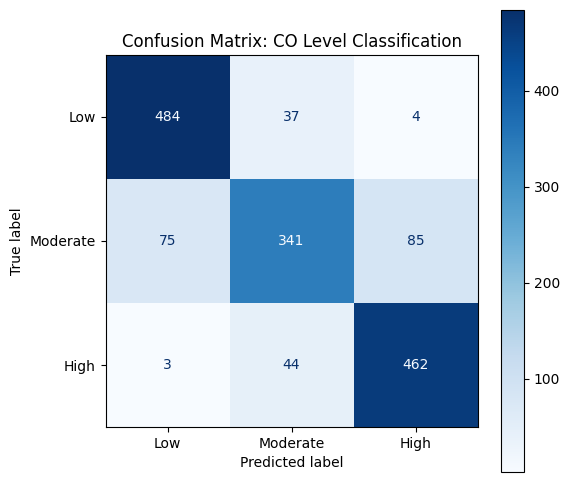

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

print(classification_report(yc_test, pred, target_names=["Low", "Moderate", "High"]))

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(yc_test, pred, display_labels=["Low", "Moderate", "High"],
                                        cmap="Blues", ax=ax)
ax.set_title("Confusion Matrix: CO Level Classification")
plt.show()

We get around 83% accuracy here. But the weakspot is definitely the moderate guesses. They were abot 68% accurate

## Setting up Baseline Regression and gettings is R2, RMSE and MAE values

In [22]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

lin_pipe = Pipeline([("preprocess", clone(preprocess_pipe)), ("reg", LinearRegression())])
lin_pipe.fit(X_train, yr_train)
pred = lin_pipe.predict(X_test)
print("RMSE:", round(root_mean_squared_error(yr_test, pred), 3), "| MAE:", round(mean_absolute_error(yr_test, pred), 3),
      "| R2:", round(r2_score(yr_test, pred), 3))

RMSE: 0.546 | MAE: 0.362 | R2: 0.857


R2 here looks good. For a linear model on somewhat complex data, .857 is a good score. But all that says is the data has real meaning behind the CO rates

MAE is low (.362). It's not a bad error though

RMSE here is about 1.5 times more than MAE. Makes sense though because RMSE punishes large errors more than MAE

## Testing regularization of Lasso and Ridge

In [23]:
alpha_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
rows, coefs = [], {}
for name, Model in [("Ridge", Ridge), ("Lasso", Lasso)]:
    for a in alpha_values:
        pipe = Pipeline([("preprocess", clone(preprocess_pipe)), ("reg", Model(alpha=a, max_iter=10000))])
        pipe.fit(X_train, yr_train)
        pred = pipe.predict(X_test)
        c = pipe.named_steps["reg"].coef_
        coefs[(name, a)] = c
        rows.append({"model": name, "alpha": a, "RMSE": root_mean_squared_error(yr_test, pred),
                     "R2": r2_score(yr_test, pred), "zero_coefs": (c == 0).sum()})
results = pd.DataFrame(rows)
results

,model,alpha,RMSE,R2,zero_coefs
0,Ridge,0.001,0.545866,0.857262,0
1,Ridge,0.010,0.545866,0.857262,0
2,Ridge,0.100,0.545872,0.857259,0
3,Ridge,1.000,0.545924,0.857232,0
4,Ridge,10.000,0.546538,0.856910,0
5,Ridge,100.000,0.553614,0.853181,0
6,Lasso,0.001,0.548738,0.855756,8
7,Lasso,0.010,0.586602,0.835163,36
8,Lasso,0.100,0.635222,0.806706,47
9,Lasso,1.000,1.199868,0.310341,50


Ridge barely moves here. It stays within the same hundredth of an R2 value and zero_coefs stays 0 throughout.
RMSE also stays within a hundredth the whole time. This makes sense as the weights will only zero out when the alpha is very large (for ridge).

Lasso is a bit different. It has 51 features and at the start, it removes 8. Though it stays close to Ridge there.
It ends up dropping all it's features and it's r2 is basically zero. Telling me it was just guessing at that point.
So for Lasso, the alpha got too high. We over regularized the model. Causing underfitting
Something to note is the R2 of lasso is still pretty strong at alpha = .1. This is when we only have 4 features left.
This tells us only about 4 features have a majority of the pull

## Coefficient Table

In [24]:
names = pipe.named_steps["preprocess"].get_feature_names_out()
coef_df = pd.DataFrame(coefs, index=names)
num_names = [n for n in names if n.startswith("num__")]
coef_df.loc[num_names].round(3)

Ridge                                           Lasso  \
                   0.001   0.010   0.100   1.000   10.000  100.000 0.001     
num__PT08.S1(CO)     0.253   0.253   0.253   0.255   0.271   0.331   0.272   
num__PT08.S2(NMHC)   0.791   0.791   0.791   0.792   0.796   0.770   0.874   
num__PT08.S3(NOx)    0.058   0.058   0.058   0.058   0.059   0.043   0.068   
num__PT08.S4(NO2)    0.395   0.395   0.395   0.392   0.370   0.282   0.301   
num__PT08.S5(O3)     0.011   0.011   0.011   0.011   0.010   0.043  -0.000   
num__T              -0.259  -0.259  -0.259  -0.259  -0.258  -0.226  -0.242   
num__RH             -0.092  -0.092  -0.092  -0.092  -0.089  -0.068  -0.079   
num__AH             -0.096  -0.096  -0.096  -0.096  -0.094  -0.109  -0.074   

                                                            
                   0.010   0.100   1.000   10.000  100.000  
num__PT08.S1(CO)     0.302   0.285   0.000     0.0     0.0  
num__PT08.S2(NMHC)   1.102   0.941   0.286     0.0     0.0  
num__PT08.S3(NOx)    0.079  -0.000  -0.000    -0.0    -0.0  
num__PT08.S4(NO2)    0.000   0.000   0.000     0.0     0.0  
num__PT08.S5(O3)     0.000   0.015   0.000     0.0     0.0  
num__T              -0.162  -0.099  -0.000     0.0     0.0  
num__RH             -0.000   0.000   0.000     0.0     0.0  
num__AH             -0.030  -0.000   0.000     0.0     0.0

I want to note that this is where we see the features lasso wanted to keep. These are likely the ones that have the most relevance to average CO levels

## Plotting coefficients against alpha

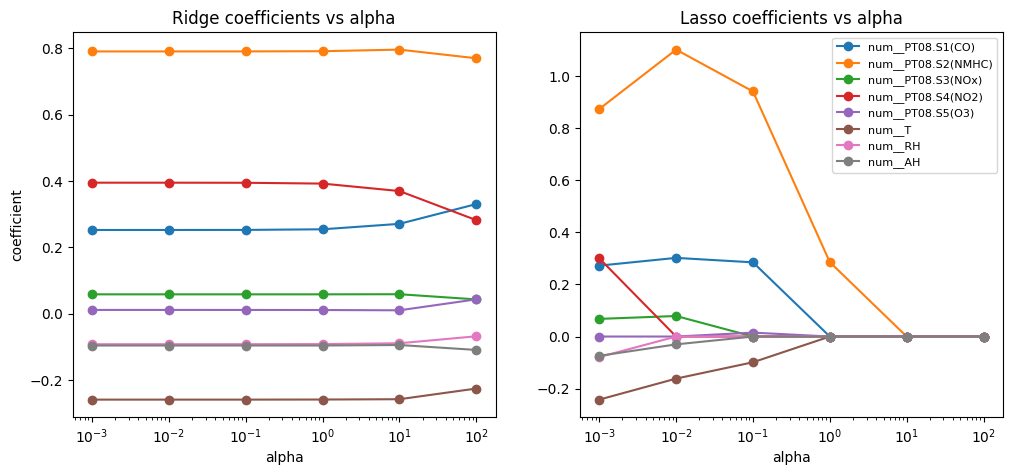

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name in zip(axes, ["Ridge", "Lasso"]):
    for f in num_names:
        ax.plot(alpha_values, [coef_df.loc[f, (name, a)] for a in alpha_values], marker="o", label=f)
    ax.set_xscale("log"); ax.set_xlabel("alpha"); ax.set_title(f"{name} coefficients vs alpha")
axes[0].set_ylabel("coefficient"); axes[1].legend(fontsize=8)
plt.show()

Here, we see a visualization of the features closing in on zero (for the most part) as alpha increases
Ridge is stable until the end where they jump around a bit. This follows our previous observations

Lasso is also consistent with our findings. It's a little more noticable here how they act though.
We see the NMHC coefficient start highest and then jump even higher while all the other features stay
near eachother (relatively). This is most likely because it had to absorb the lost weight of the
features lasso decided to drop. This plot is basically telling us the NMHC sensor is the single
strongest predictor of average CO levels per hour.

## Comparing MinMaxScaler and StandardScaler

In [26]:
from sklearn.preprocessing import MinMaxScaler

rows = []
for scaler in [StandardScaler(), MinMaxScaler()]:
    num_pipe_s = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scale", scaler)])
    cat_pipe_s = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                           ("encoder", OneHotEncoder(handle_unknown="ignore"))])
    prep = ColumnTransformer([("num", num_pipe_s, num_cols), ("cat", cat_pipe_s, cat_cols)])

    clf = Pipeline([("preprocess", clone(prep)), ("model", LogisticRegression(max_iter=1000, random_state=42))])
    clf.fit(X_train, yc_train)
    reg = Pipeline([("preprocess", clone(prep)), ("model", Lasso(alpha=0.01, max_iter=10000))])
    reg.fit(X_train, yr_train)

    rows.append({"scaler": type(scaler).__name__,
                 "clf_accuracy": accuracy_score(yc_test, clf.predict(X_test)),
                 "clf_iters": clf.named_steps["model"].n_iter_[0],
                 "lasso_R2": r2_score(yr_test, reg.predict(X_test)),
                 "lasso_zero_coefs": (reg.named_steps["model"].coef_ == 0).sum()})
pd.DataFrame(rows).round(3)

,scaler,clf_accuracy,clf_iters,lasso_R2,lasso_zero_coefs
0,StandardScaler,0.862,51,0.835,36
1,MinMaxScaler,0.853,64,0.834,35


The two models basically tie with cose to the same R2 value and 35 v 36 coefficients zeroed
But StandardScaler is a bit more accurate and has less iterations